In [1]:
import bitsandbytes as bnb
import torch
test = torch.randn(64, 64).cuda()
q, s = bnb.functional.quantize(test)
print("INT8: SUCCESS")
linear = bnb.nn.Linear4bit(64, 64).cuda()
print("INT4: SUCCESS")

This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=



INT8: SUCCESS
INT4: SUCCESS


/tmp/ipykernel_3572147/268854180.py:4: FutureWarning: This function is deprecated and will be removed in a future release.
  q, s = bnb.functional.quantize(test)
/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/bitsandbytes/functional.py:1080: FutureWarning: This function is deprecated and will be removed in a future release.
  out = quantize_no_absmax(inp, code, out)


In [2]:
import torch
import vllm
import transformers

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"vLLM: {vllm.__version__}")
print(f"Transformers: {transformers.__version__}")

INFO 03-29 20:59:19 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 03-29 20:59:19 [__init__.py:239] Automatically detected platform cuda.
PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB
vLLM: 0.8.5
Transformers: 4.57.1


In [3]:
import torch
import time
import json
import warnings
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from vllm import LLM, SamplingParams
warnings.filterwarnings("ignore")

In [4]:
# Config 
HF_CACHE = "/data/datasets/community/huggingface"

MODELS = {
    "Llama-3.1-8B": {
        "path": f"{HF_CACHE}/models--meta-llama--Llama-3.1-8B-Instruct",
        "hf_id": "meta-llama/Llama-3.1-8B-Instruct",
        "family": "Llama",
        "params": "8B",
    },
    "Qwen3-4B": {
        "path": f"{HF_CACHE}/models--Qwen--Qwen3-4B",
        "hf_id": "Qwen/Qwen3-4B",
        "family": "Qwen",
        "params": "4B",
    },
    "DeepSeek-R1-8B": {
        "path": f"{HF_CACHE}/models--deepseek-ai--DeepSeek-R1-Distill-Llama-8B",
        "hf_id": "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
        "family": "DeepSeek",
        "params": "8B",
    },
    "Falcon3-10B": {
    "path": f"{HF_CACHE}/models--tiiuae--Falcon3-10B-Instruct",
    "hf_id": "tiiuae/Falcon3-10B-Instruct",
    "family": "Falcon",
    "params": "10B",
    },
}

PROMPT = "Explain the concept of transformer attention mechanism and why it revolutionized natural language processing."
MAX_NEW_TOKENS = 200
NUM_RUNS = 3  

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"\nModels to benchmark: {list(MODELS.keys())}")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB

Models to benchmark: ['Llama-3.1-8B', 'Qwen3-4B', 'DeepSeek-R1-8B', 'Falcon3-10B']


# Helper Functions

In [5]:
def get_gpu_memory_used():
    """Returns GPU memory used in GB"""
    return torch.cuda.memory_allocated() / 1e9

def get_gpu_memory_reserved():
    """Returns GPU memory reserved in GB"""
    return torch.cuda.memory_reserved() / 1e9

def clear_gpu():
    """Clear GPU memory between runs"""
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    import gc; gc.collect()

def get_snapshot_vram():
    """Peak VRAM used in GB"""
    return torch.cuda.max_memory_allocated() / 1e9

def find_model_snapshot_path(model_info):
    """Find the actual snapshot path inside HF cache folder"""
    base = Path(model_info["path"])
    snapshots = list((base / "snapshots").glob("*"))
    if snapshots:
        return str(snapshots[0])
    return str(base)

def print_result(name, precision, result):
    print(f"\n{'─'*55}")
    print(f"  {name} | {precision}")
    print(f"{'─'*55}")
    print(f"  Load time:        {result['load_time']:.2f}s")
    print(f"  Time to 1st tok:  {result['ttft_ms']:.1f}ms")
    print(f"  Throughput:       {result['tokens_per_sec']:.1f} tok/s")
    print(f"  VRAM used:        {result['vram_gb']:.2f} GB")
    print(f"  Tokens generated: {result['tokens_generated']}")

# HuggingFace FP16 Benchmark

In [6]:
def benchmark_hf(model_name, model_info, precision="fp16"):
    """Benchmark a model using HuggingFace Transformers"""
    
    print(f"\n{'='*55}")
    print(f"  Benchmarking: {model_name} [{precision.upper()}] via HuggingFace")
    print(f"{'='*55}")
    
    model_path = find_model_snapshot_path(model_info)
    print(f"  Loading from: {model_path}")
    
    clear_gpu()
    torch.cuda.reset_peak_memory_stats()
    
# Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_path, 
        trust_remote_code=True,
        local_files_only=True
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
# Load model 
    load_start = time.time()
    
    if precision == "fp16":
        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=True,
            local_files_only=True
        )
    elif precision == "int8":
        bnb_config = BitsAndBytesConfig(load_in_8bit=True)
        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
            local_files_only=True
        )
    elif precision == "int4":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )
        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
            local_files_only=True
        )
    
    load_time = time.time() - load_start
    vram_after_load = get_snapshot_vram()
    print(f"  Model loaded in {load_time:.1f}s | VRAM: {vram_after_load:.2f} GB")
    
# Warmup 
    inputs = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=10, do_sample=False)
    
# Benchmark runs
    ttft_list, tps_list = [], []
    
    for run in range(NUM_RUNS):
        inputs = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)
        torch.cuda.synchronize()
        
        t0 = time.perf_counter()
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                temperature=None,
                top_p=None,
            )
        torch.cuda.synchronize()
        total_time = time.perf_counter() - t0
        
        input_len = inputs["input_ids"].shape[1]
        tokens_generated = output.shape[1] - input_len
        tps = tokens_generated / total_time
        ttft = (total_time / tokens_generated) * 1000  # approx ms per token
        
        ttft_list.append(ttft)
        tps_list.append(tps)
        print(f"  Run {run+1}: {tps:.1f} tok/s | {ttft:.1f}ms/tok")
    
    result = {
        "model": model_name,
        "precision": precision,
        "backend": "HuggingFace",
        "load_time": load_time,
        "ttft_ms": np.mean(ttft_list),
        "tokens_per_sec": np.mean(tps_list),
        "vram_gb": vram_after_load,
        "tokens_generated": tokens_generated,
    }
    
    print_result(model_name, precision, result)
    
# Cleanup
    del model
    clear_gpu()
    
    return result

# Run HF benchmarks 
hf_results = []

for model_name, model_info in MODELS.items():
    for precision in ["fp16", "int8", "int4"]:
        try:
            result = benchmark_hf(model_name, model_info, precision)
            hf_results.append(result)
        except Exception as e:
            print(f"  FAILED {model_name} {precision}: {e}")
            hf_results.append({
                "model": model_name, "precision": precision,
                "backend": "HuggingFace", "load_time": None,
                "ttft_ms": None, "tokens_per_sec": None,
                "vram_gb": None, "tokens_generated": None,
            })
        clear_gpu()

print("\nHuggingFace benchmarks complete!")


  Benchmarking: Llama-3.1-8B [FP16] via HuggingFace
  Loading from: /data/datasets/community/huggingface/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  Model loaded in 2.4s | VRAM: 16.99 GB


...

  Model loaded in 12.9s | VRAM: 7.33 GB


Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


  Run 1: 16.4 tok/s | 61.1ms/tok


Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


  Run 2: 16.4 tok/s | 61.1ms/tok
  Run 3: 16.4 tok/s | 61.1ms/tok

───────────────────────────────────────────────────────
  Falcon3-10B | int4
───────────────────────────────────────────────────────
  Load time:        12.92s
  Time to 1st tok:  61.1ms
  Throughput:       16.4 tok/s
  VRAM used:        7.33 GB
  Tokens generated: 200

HuggingFace benchmarks complete!


#  vLLM Benchmark

In [7]:
def benchmark_vllm(model_name, model_info):
    """Benchmark using vLLM backend"""
    
    print(f"\n{'='*55}")
    print(f"  Benchmarking: {model_name} via vLLM")
    print(f"{'='*55}")
    
    model_path = find_model_snapshot_path(model_info)
    
    clear_gpu()
    torch.cuda.reset_peak_memory_stats()
    
# Load with vLLM 
    load_start = time.time()
    try:
        llm = LLM(
            model=model_path,
            trust_remote_code=True,
            dtype="float16",
            gpu_memory_utilization=0.85,
            max_model_len=2048,
            enforce_eager=True,      
            compilation_config=None, 
        )
    except Exception as e:
        print(f"vLLM load failed: {e}")
        return None
    
    load_time = time.time() - load_start
    vram_used = torch.cuda.memory_reserved() / 1e9
    print(f" Loaded in {load_time:.1f}s | VRAM: {vram_used:.2f} GB")
    
    sampling_params = SamplingParams(
        temperature=0.0,
        max_tokens=MAX_NEW_TOKENS
    )
    
# Warmup 
    _ = llm.generate([PROMPT], SamplingParams(temperature=0.0, max_tokens=10))
    
    # ── Benchmark runs ──
    ttft_list, tps_list = [], []
    
    for run in range(NUM_RUNS):
        t0 = time.perf_counter()
        outputs = llm.generate([PROMPT], sampling_params)
        total_time = time.perf_counter() - t0
        
        tokens_generated = len(outputs[0].outputs[0].token_ids)
        tps = tokens_generated / total_time
        ttft = (total_time / tokens_generated) * 1000
        
        ttft_list.append(ttft)
        tps_list.append(tps)
        print(f"  Run {run+1}: {tps:.1f} tok/s | {ttft:.1f}ms/tok")
    
    result = {
        "model": model_name,
        "precision": "fp16",
        "backend": "vLLM",
        "load_time": load_time,
        "ttft_ms": np.mean(ttft_list),
        "tokens_per_sec": np.mean(tps_list),
        "vram_gb": vram_used,
        "tokens_generated": tokens_generated,
    }
    
    print_result(model_name, model_info, result)
    
    del llm
    clear_gpu()
    
    return result

# Run vLLM benchmarks 
vllm_results = []

for model_name, model_info in MODELS.items():
    try:
        result = benchmark_vllm(model_name, model_info)
        if result:
            vllm_results.append(result)
    except Exception as e:
        print(f"  FAILED {model_name}: {e}")
    clear_gpu()

print("\nvLLM benchmarks complete!")


  Benchmarking: Llama-3.1-8B via vLLM
WARNING 03-29 21:11:41 [config.py:2972] Casting torch.bfloat16 to torch.float16.
INFO 03-29 21:11:59 [config.py:717] This model supports multiple tasks: {'generate', 'score', 'reward', 'embed', 'classify'}. Defaulting to 'generate'.
INFO 03-29 21:11:59 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
WARNING 03-29 21:11:59 [cuda.py:93] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
WARNING 03-29 21:11:59 [utils.py:2382] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/getting_started/troubleshooting.html#python-multiprocessing for more information. Reason: CUDA is initialized
INFO 03-29 21:12:04 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 03-29 21:12:05 [__init__.py:239] Automatically detected platform cuda.
INF

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:04<00:12,  4.04s/it]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:08<00:08,  4.21s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:12<00:04,  4.31s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:13<00:00,  3.08s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:13<00:00,  3.50s/it]



INFO 03-29 21:12:23 [loader.py:458] Loading weights took 14.03 seconds
INFO 03-29 21:12:23 [gpu_model_runner.py:1347] Model loading took 14.9889 GiB and 14.162726 seconds
INFO 03-29 21:12:24 [kv_cache_utils.py:634] GPU KV cache size: 266,848 tokens
INFO 03-29 21:12:24 [kv_cache_utils.py:637] Maximum concurrency for 2,048 tokens per request: 130.30x
INFO 03-29 21:12:25 [core.py:159] init engine (profile, create kv cache, warmup model) took 1.57 seconds
INFO 03-29 21:12:25 [core_client.py:439] Core engine process 0 ready.
 Loaded in 43.5s | VRAM: 15.01 GB


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

  Run 2: 63.0 tok/s | 15.9ms/tok


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  Run 3: 63.0 tok/s | 15.9ms/tok

───────────────────────────────────────────────────────
  Falcon3-10B | {'path': '/data/datasets/community/huggingface/models--tiiuae--Falcon3-10B-Instruct', 'hf_id': 'tiiuae/Falcon3-10B-Instruct', 'family': 'Falcon', 'params': '10B'}
───────────────────────────────────────────────────────
  Load time:        30.63s
  Time to 1st tok:  15.9ms
  Throughput:       62.9 tok/s
  VRAM used:        15.01 GB
  Tokens generated: 200


[rank0]:[W329 21:14:37.378325332 ProcessGroupNCCL.cpp:1496] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())



vLLM benchmarks complete!


In [8]:
import pandas as pd

# Load saved results 
df = pd.read_csv("/data/pjiang18/SLP/LLMBenchmark/results/benchmark_results.csv")
df["backend_precision"] = df["backend"] + "-" + df["precision"]
df["efficiency"] = df["tokens_per_sec"] / df["vram_gb"]

print(f"Loaded {len(df)} benchmark results")
print(df[["model","backend","precision","tokens_per_sec","vram_gb"]].to_string(index=False))

Loaded 16 benchmark results
         model     backend precision  tokens_per_sec   vram_gb
  Llama-3.1-8B HuggingFace      fp16       43.728932 16.993731
  Llama-3.1-8B HuggingFace      int8       10.644983 10.087137
  Llama-3.1-8B HuggingFace      int4       21.044670  6.734120
      Qwen3-4B HuggingFace      fp16       30.445986  8.103272
      Qwen3-4B HuggingFace      int8        7.692202  4.524581
      Qwen3-4B HuggingFace      int4       16.356236  2.778845
DeepSeek-R1-8B HuggingFace      fp16       43.385767 16.102581
DeepSeek-R1-8B HuggingFace      int8       10.936545  9.288107
DeepSeek-R1-8B HuggingFace      int4       20.954204  5.936422
   Falcon3-10B HuggingFace      fp16       34.448265 21.317113
   Falcon3-10B HuggingFace      int8        7.495104 11.863401
   Falcon3-10B HuggingFace      int4       16.770776  7.326231
  Llama-3.1-8B        vLLM      fp16       84.010442 15.011414
      Qwen3-4B        vLLM      fp16       49.237865 15.011414
DeepSeek-R1-8B        vLLM 

# Combine Results

In [9]:
# Combine all results
all_results = hf_results + vllm_results
df = pd.DataFrame(all_results)

# Drop failed runs
df = df.dropna(subset=["tokens_per_sec"])

# Save results
results_path = "/data/pjiang18/SLP/LLMBenchmark/benchmark_results.csv"
df.to_csv(results_path, index=False)
print("Results saved!")
print(f"\n{df[['model','backend','precision','tokens_per_sec','vram_gb','load_time']].to_string(index=False)}")

Results saved!

         model     backend precision  tokens_per_sec   vram_gb  load_time
  Llama-3.1-8B HuggingFace      fp16       44.495868 16.993758   2.433282
  Llama-3.1-8B HuggingFace      int8       10.728351 10.087165   9.995516
  Llama-3.1-8B HuggingFace      int4       21.171336  6.734147  10.312845
      Qwen3-4B HuggingFace      fp16       28.673175  8.103299   9.665356
      Qwen3-4B HuggingFace      int8        7.487012  4.524607   3.975728
      Qwen3-4B HuggingFace      int4       15.755548  2.778872   4.992989
DeepSeek-R1-8B HuggingFace      fp16       41.599402 16.102608 101.726281
DeepSeek-R1-8B HuggingFace      int8       10.654233  9.288134  10.850409
DeepSeek-R1-8B HuggingFace      int4       20.310631  5.936449  11.022081
   Falcon3-10B HuggingFace      fp16       32.654395 21.317139  24.991907
   Falcon3-10B HuggingFace      int8        7.348747 11.863428  34.585027
   Falcon3-10B HuggingFace      int4       16.366568  7.326257  12.917400
  Llama-3.1-8B        

#  Visualizations

Saved: /data/pjiang18/SLP/LLMBenchmark/results/01_vllm_vs_hf_throughput.png


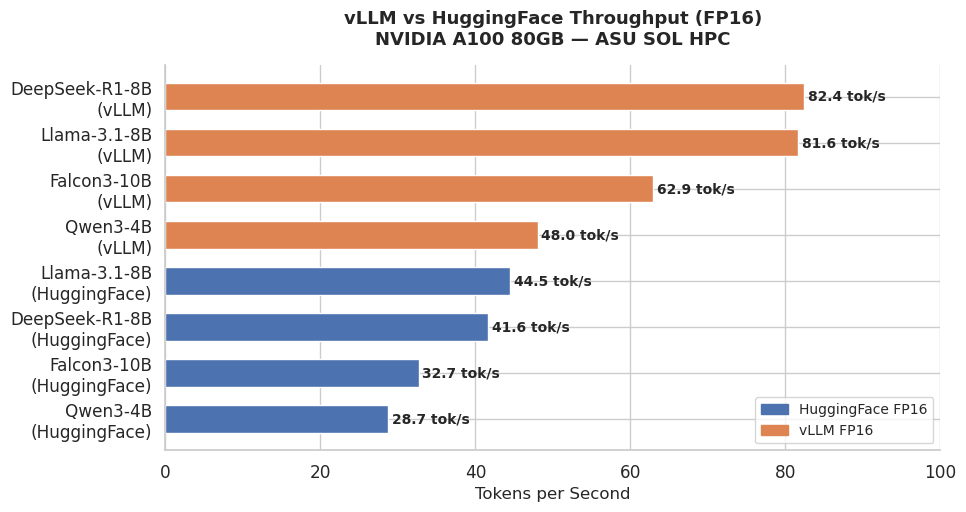

Saved: /data/pjiang18/SLP/LLMBenchmark/results/02_quantization_throughput.png


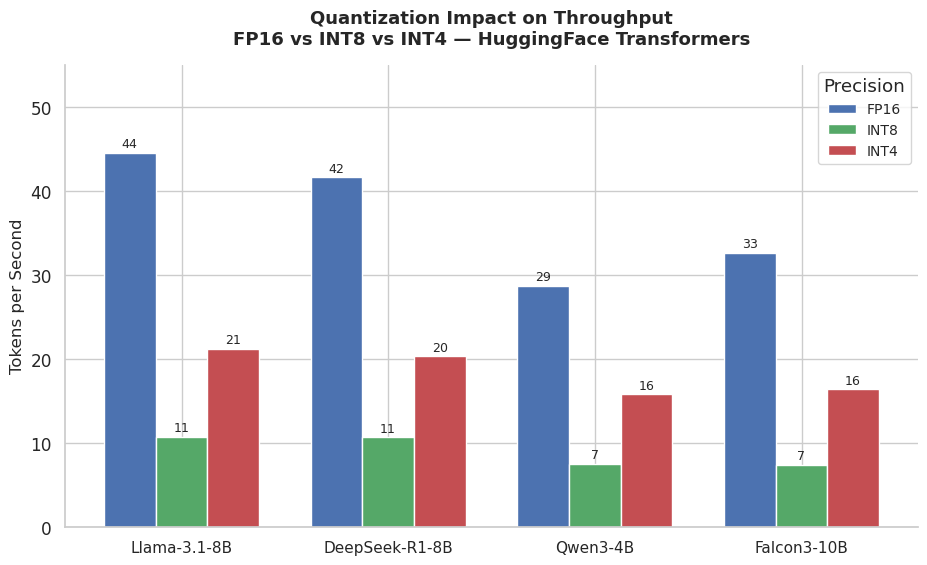

Saved: /data/pjiang18/SLP/LLMBenchmark/results/03_quantization_vram.png


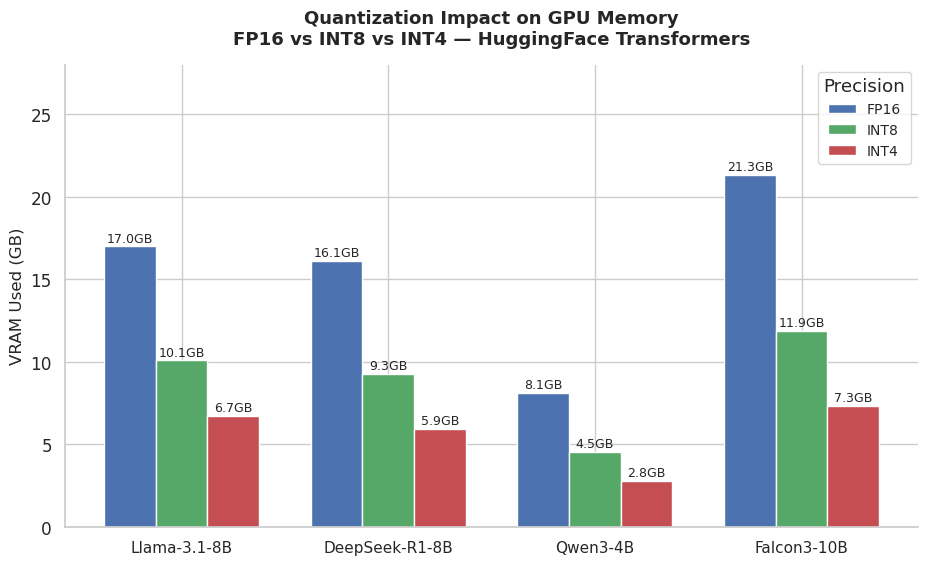

Saved: /data/pjiang18/SLP/LLMBenchmark/results/04_throughput_vs_vram_scatter.png


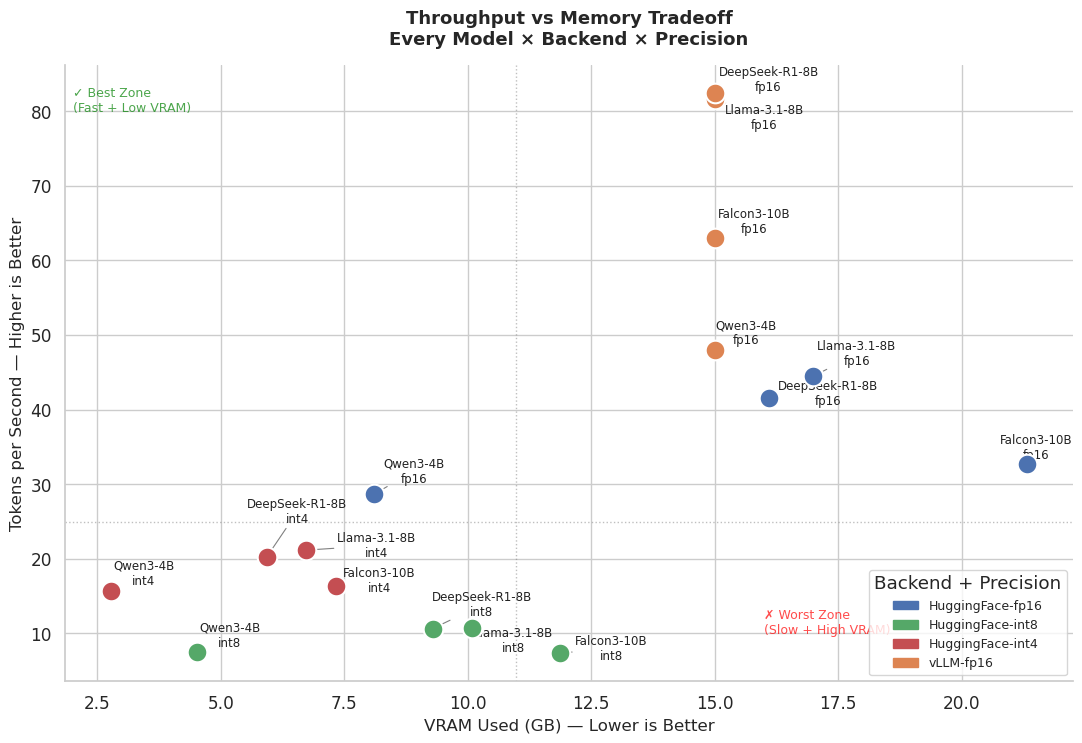

Saved: /data/pjiang18/SLP/LLMBenchmark/results/05_efficiency_score.png


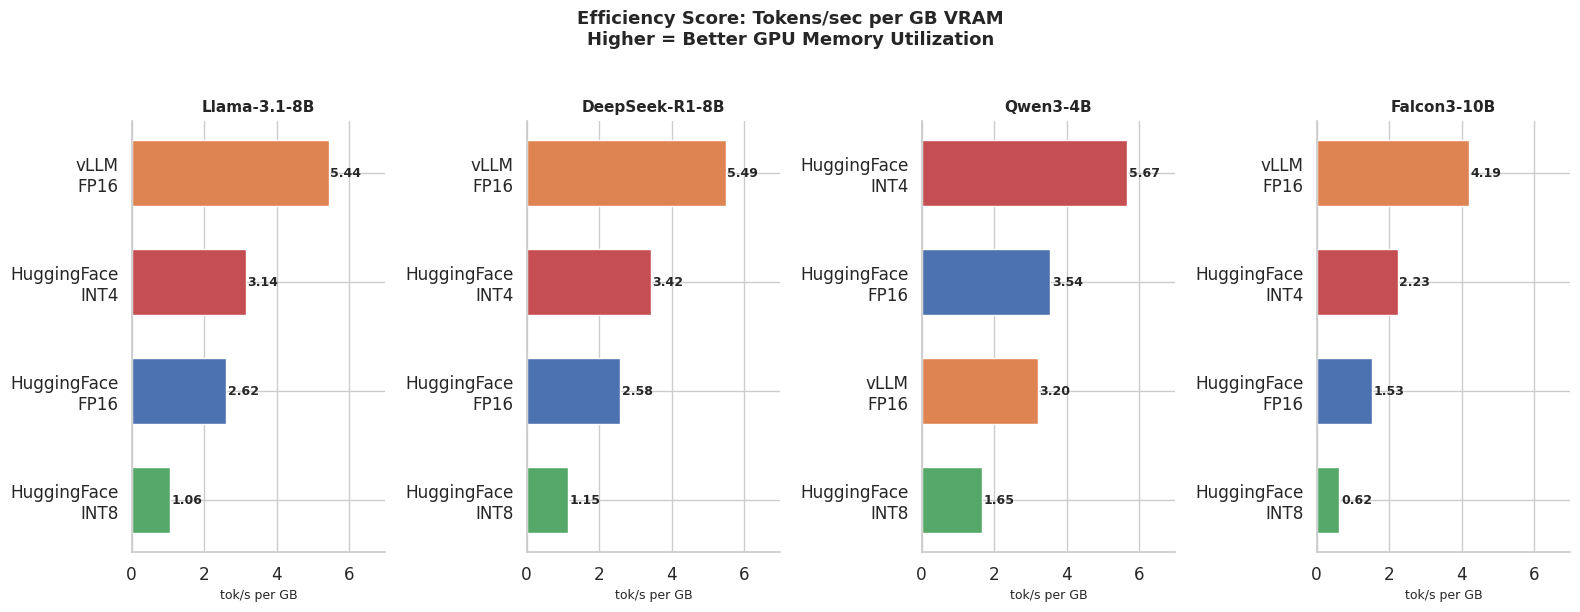

Saved: /data/pjiang18/SLP/LLMBenchmark/results/06_vllm_speedup.png


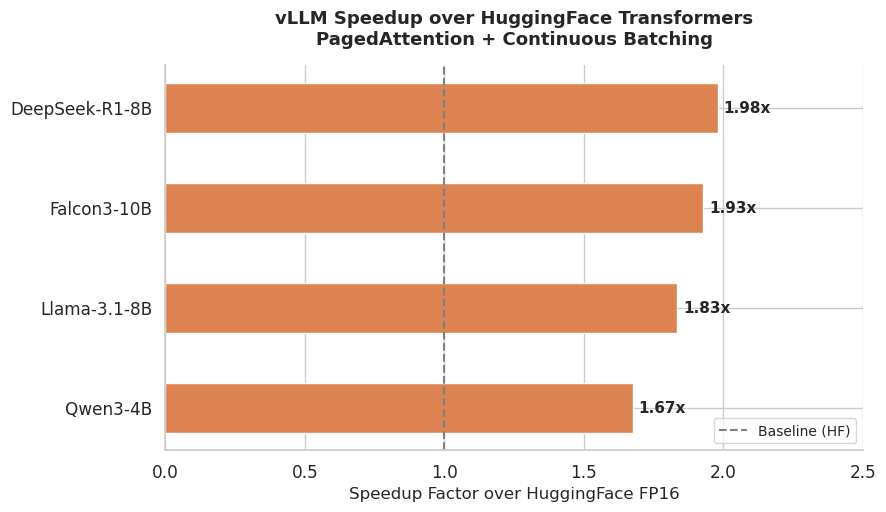


All 6 charts saved to results/


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np

# Style 
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {
    "HuggingFace-fp16": "#4C72B0",
    "HuggingFace-int8": "#55A868",
    "HuggingFace-int4": "#C44E52",
    "vLLM-fp16":        "#DD8452",
}
MODEL_ORDER = ["Llama-3.1-8B", "DeepSeek-R1-8B", "Qwen3-4B", "Falcon3-10B"]
SAVE_DIR = "/data/pjiang18/SLP/LLMBenchmark/results/"

df["backend_precision"] = df["backend"] + "-" + df["precision"]
df["color"] = df["backend_precision"].map(COLORS)

def save(fig, name):
    path = f"{SAVE_DIR}{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

# Legend handles
legend_handles = [
    mpatches.Patch(color=v, label=k) for k, v in COLORS.items()
]


# Chart 1 — vLLM vs HuggingFace Throughput (FP16 only)
fig, ax = plt.subplots(figsize=(10, 5))
fp16_df = df[df["precision"] == "fp16"].copy()
fp16_df = fp16_df.sort_values("tokens_per_sec", ascending=True)

bars = ax.barh(
    fp16_df["model"] + "\n(" + fp16_df["backend"] + ")",
    fp16_df["tokens_per_sec"],
    color=fp16_df["color"],
    edgecolor="white", height=0.6
)
for bar, val in zip(bars, fp16_df["tokens_per_sec"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} tok/s", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Tokens per Second", fontsize=12)
ax.set_title("vLLM vs HuggingFace Throughput (FP16)\nNVIDIA A100 80GB — ASU SOL HPC",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(handles=[
    mpatches.Patch(color=COLORS["HuggingFace-fp16"], label="HuggingFace FP16"),
    mpatches.Patch(color=COLORS["vLLM-fp16"], label="vLLM FP16"),
], fontsize=10)
ax.set_xlim(0, 100)
sns.despine()
save(fig, "01_vllm_vs_hf_throughput")


# Chart 2 — Quantization: Throughput vs Precision (HF only)
fig, ax = plt.subplots(figsize=(11, 6))
hf_df = df[df["backend"] == "HuggingFace"].copy()

x = np.arange(len(MODEL_ORDER))
width = 0.25
prec_colors = {"fp16": COLORS["HuggingFace-fp16"],
               "int8": COLORS["HuggingFace-int8"],
               "int4": COLORS["HuggingFace-int4"]}

for i, (prec, color) in enumerate(prec_colors.items()):
    vals = [hf_df[(hf_df["model"]==m) & (hf_df["precision"]==prec)]["tokens_per_sec"].values[0]
            for m in MODEL_ORDER]
    bars = ax.bar(x + (i-1)*width, vals, width, label=prec.upper(),
                  color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.0f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylabel("Tokens per Second", fontsize=12)
ax.set_title("Quantization Impact on Throughput\nFP16 vs INT8 vs INT4 — HuggingFace Transformers",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(title="Precision", fontsize=10)
ax.set_ylim(0, 55)
sns.despine()
save(fig, "02_quantization_throughput")

# Chart 3 — Quantization: VRAM vs Precision
fig, ax = plt.subplots(figsize=(11, 6))

for i, (prec, color) in enumerate(prec_colors.items()):
    vals = [hf_df[(hf_df["model"]==m) & (hf_df["precision"]==prec)]["vram_gb"].values[0]
            for m in MODEL_ORDER]
    bars = ax.bar(x + (i-1)*width, vals, width, label=prec.upper(),
                  color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val:.1f}GB", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=11)
ax.set_ylabel("VRAM Used (GB)", fontsize=12)
ax.set_title("Quantization Impact on GPU Memory\nFP16 vs INT8 vs INT4 — HuggingFace Transformers",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(title="Precision", fontsize=10)
ax.set_ylim(0, 28)
sns.despine()
save(fig, "03_quantization_vram")


# Chart 4 — Throughput vs VRAM Tradeoff (scatter) 
from adjustText import adjust_text
fig, ax = plt.subplots(figsize=(13, 8))

texts = []
for _, row in df.iterrows():
    color = COLORS.get(row["backend_precision"], "#888")
    ax.scatter(row["vram_gb"], row["tokens_per_sec"],
               color=color, s=200, zorder=5, 
               edgecolors="white", linewidths=1.5)
    texts.append(ax.text(
        row["vram_gb"], row["tokens_per_sec"],
        f"{row['model']}\n{row['precision']}",
        fontsize=8.5, color="#222222"
    ))


try:
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.8))
except:
    pass  

ax.set_xlabel("VRAM Used (GB) — Lower is Better", fontsize=12)
ax.set_ylabel("Tokens per Second — Higher is Better", fontsize=12)
ax.set_title("Throughput vs Memory Tradeoff\nEvery Model × Backend × Precision",
             fontsize=13, fontweight="bold", pad=15)
ax.legend(handles=legend_handles, fontsize=9, 
          title="Backend + Precision", loc="lower right")

# Add quadrant shading
ax.axhline(y=df["tokens_per_sec"].median(), color="gray", 
           linestyle=":", alpha=0.5, linewidth=1)
ax.axvline(x=df["vram_gb"].median(), color="gray", 
           linestyle=":", alpha=0.5, linewidth=1)
ax.text(2, 80, "✓ Best Zone\n(Fast + Low VRAM)", 
        fontsize=9, color="green", alpha=0.7)
ax.text(16, 10, "✗ Worst Zone\n(Slow + High VRAM)", 
        fontsize=9, color="red", alpha=0.7)

sns.despine()
save(fig, "04_throughput_vs_vram_scatter")


# Chart 5 — Efficiency Score 
df["efficiency"] = df["tokens_per_sec"] / df["vram_gb"]

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=False)
fig.suptitle("Efficiency Score: Tokens/sec per GB VRAM\nHigher = Better GPU Memory Utilization",
             fontsize=13, fontweight="bold", y=1.02)

for ax, model in zip(axes, MODEL_ORDER):
    model_df = df[df["model"] == model].copy()
    model_df["label"] = model_df["backend"] + "\n" + model_df["precision"].str.upper()
    model_df = model_df.sort_values("efficiency", ascending=True)
    
    bars = ax.barh(model_df["label"], model_df["efficiency"],
                   color=model_df["color"], edgecolor="white", height=0.6)
    
    for bar, val in zip(bars, model_df["efficiency"]):
        ax.text(bar.get_width() + 0.05,
                bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=9, fontweight="bold")
    
    ax.set_title(model, fontsize=11, fontweight="bold")
    ax.set_xlabel("tok/s per GB", fontsize=9)
    ax.set_xlim(0, 7)
    sns.despine(ax=ax)

plt.tight_layout()
save(fig, "05_efficiency_score")




# Chart 6 — Speedup: vLLM over HuggingFace
fig, ax = plt.subplots(figsize=(9, 5))

speedups = []
for model in MODEL_ORDER:
    hf_tps = df[(df["model"]==model) & (df["backend"]=="HuggingFace") &
                (df["precision"]=="fp16")]["tokens_per_sec"].values[0]
    vllm_tps = df[(df["model"]==model) & (df["backend"]=="vLLM") &
                  (df["precision"]=="fp16")]["tokens_per_sec"].values[0]
    speedups.append({"model": model, "speedup": vllm_tps / hf_tps})

speedup_df = pd.DataFrame(speedups).sort_values("speedup")
bars = ax.barh(speedup_df["model"], speedup_df["speedup"],
               color=COLORS["vLLM-fp16"], edgecolor="white", height=0.5)
ax.axvline(x=1, color="gray", linestyle="--", linewidth=1.5, label="Baseline (HF)")
for bar, val in zip(bars, speedup_df["speedup"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}x", va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Speedup Factor over HuggingFace FP16", fontsize=12)
ax.set_title("vLLM Speedup over HuggingFace Transformers\nPagedAttention + Continuous Batching",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlim(0, 2.5)
ax.legend(fontsize=10)
sns.despine()
save(fig, "06_vllm_speedup")

print("\nAll 6 charts saved to results/")

# Summary Table

In [11]:
print("\n" + "="*70)
print("  FINAL BENCHMARK SUMMARY| NVIDIA A100 80GB")
print("="*70)

summary = df[["model","backend","precision","tokens_per_sec",
              "vram_gb","load_time","efficiency"]].copy()
summary.columns = ["Model","Backend","Precision","Tok/s","VRAM(GB)","Load(s)","Tok/s/GB"]
summary = summary.sort_values("Tok/s", ascending=False)

print(summary.to_string(index=False, float_format="{:.2f}".format))

print("\n Fastest model:", summary.iloc[0]["Model"], 
      f"({summary.iloc[0]['Backend']} {summary.iloc[0]['Precision']})",
      f"— {summary.iloc[0]['Tok/s']:.1f} tok/s")
print(" Most efficient:", summary.sort_values("Tok/s/GB", ascending=False).iloc[0]["Model"],
      f"— {summary.sort_values('Tok/s/GB', ascending=False).iloc[0]['Tok/s/GB']:.2f} tok/s/GB")
print(" Lowest VRAM:", summary.sort_values("VRAM(GB)").iloc[0]["Model"],
      f"— {summary.sort_values('VRAM(GB)').iloc[0]['VRAM(GB)']:.1f} GB")


  FINAL BENCHMARK SUMMARY| NVIDIA A100 80GB
         Model     Backend Precision  Tok/s  VRAM(GB)  Load(s)  Tok/s/GB
DeepSeek-R1-8B        vLLM      fp16  82.40     15.01    25.75      5.49
  Llama-3.1-8B        vLLM      fp16  81.65     15.01    43.50      5.44
   Falcon3-10B        vLLM      fp16  62.95     15.01    30.63      4.19
      Qwen3-4B        vLLM      fp16  48.02     15.01    29.04      3.20
  Llama-3.1-8B HuggingFace      fp16  44.50     16.99     2.43      2.62
DeepSeek-R1-8B HuggingFace      fp16  41.60     16.10   101.73      2.58
   Falcon3-10B HuggingFace      fp16  32.65     21.32    24.99      1.53
      Qwen3-4B HuggingFace      fp16  28.67      8.10     9.67      3.54
  Llama-3.1-8B HuggingFace      int4  21.17      6.73    10.31      3.14
DeepSeek-R1-8B HuggingFace      int4  20.31      5.94    11.02      3.42
   Falcon3-10B HuggingFace      int4  16.37      7.33    12.92      2.23
      Qwen3-4B HuggingFace      int4  15.76      2.78     4.99      5.67
  Llam


# EXPERIMENT 2: Speculative Decoding


In [12]:
# Draft model: Qwen3-4B (small, fast)
# Target model: Llama-3.1-8B (large, accurate)
# Concept: Draft model guesses tokens, target model verifies in parallel
# Result: Target model quality at closer to draft model speed

In [13]:
import time
import os
import torch
import numpy as np
import pandas as pd
from vllm import LLM, SamplingParams

HF_CACHE = "/data/datasets/community/huggingface"
SPEC_PROMPTS = [
    "Explain how transformer attention mechanisms work in detail.",
    "What are the key differences between supervised and unsupervised learning?",
    "Describe the process of backpropagation in neural networks.",
    "What is the vanishing gradient problem and how is it solved?",
    "Explain the architecture of a convolutional neural network.",
]

TARGET_MODEL = f"{HF_CACHE}/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659"
DRAFT_MODEL  = f"{HF_CACHE}/models--Qwen--Qwen3-4B/snapshots/82d62bb073771e7a1ea59435f548908540217d1f"

sampling_params = SamplingParams(temperature=0.0, max_tokens=200)
spec_results = []

def clear_gpu():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    import gc; gc.collect()

# Baseline: Target model alone
print("="*55)
print("  BASELINE: Llama-3.1-8B alone (no speculative decoding)")
print("="*55)

os.environ["VLLM_USE_V1"] = "1"
clear_gpu()
load_start = time.time()
llm_baseline = LLM(
    model=TARGET_MODEL,
    trust_remote_code=True,
    dtype="float16",
    gpu_memory_utilization=0.85,
    max_model_len=2048,
    enforce_eager=True,
)
load_time = time.time() - load_start
print(f"  Loaded in {load_time:.1f}s")

# Warmup
_ = llm_baseline.generate(SPEC_PROMPTS[:1],
    SamplingParams(temperature=0.0, max_tokens=10))

# Benchmark
times, tps_list = [], []
for run in range(3):
    t0 = time.perf_counter()
    outputs = llm_baseline.generate(SPEC_PROMPTS, sampling_params)
    total_time = time.perf_counter() - t0
    total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
    tps = total_tokens / total_time
    times.append(total_time)
    tps_list.append(tps)
    print(f"  Run {run+1}: {tps:.1f} tok/s | {total_time:.2f}s total")

baseline_tps = np.mean(tps_list)
spec_results.append({
    "method": "No Speculation\n(Llama-3.1-8B alone)",
    "tokens_per_sec": baseline_tps,
    "load_time": load_time,
    "speedup": 1.0,
})
print(f"\n  Baseline avg: {baseline_tps:.1f} tok/s")

del llm_baseline
clear_gpu()

# Speculative Decoding 
print("\n" + "="*55)
print("  SPECULATIVE DECODING: Qwen3-4B → Llama-3.1-8B")
print("  Draft model proposes tokens, target verifies")
print("="*55)

os.environ["VLLM_USE_V1"] = "0"  # V0 required for speculative decoding
clear_gpu()
load_start = time.time()

try:
    llm_spec = LLM(
        model=TARGET_MODEL,
        speculative_config={
            "model": DRAFT_MODEL,
            "num_speculative_tokens": 5,
        },
        trust_remote_code=True,
        dtype="float16",
        gpu_memory_utilization=0.85,
        max_model_len=2048,
        enforce_eager=True,
    )
    load_time = time.time() - load_start
    print(f"  Loaded in {load_time:.1f}s")

    # Warmup
    _ = llm_spec.generate(SPEC_PROMPTS[:1],
        SamplingParams(temperature=0.0, max_tokens=10))

    # Benchmark
    times, tps_list = [], []
    for run in range(3):
        t0 = time.perf_counter()
        outputs = llm_spec.generate(SPEC_PROMPTS, sampling_params)
        total_time = time.perf_counter() - t0
        total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
        tps = total_tokens / total_time
        times.append(total_time)
        tps_list.append(tps)
        print(f"  Run {run+1}: {tps:.1f} tok/s | {total_time:.2f}s total")

    spec_tps = np.mean(tps_list)
    speedup = spec_tps / baseline_tps
    spec_results.append({
        "method": "Speculative Decoding\n(Qwen3-4B → Llama-3.1-8B)",
        "tokens_per_sec": spec_tps,
        "load_time": load_time,
        "speedup": speedup,
    })
    print(f"\n  Speculative avg: {spec_tps:.1f} tok/s")
    print(f"  Speedup over baseline: {speedup:.2f}x")

    del llm_spec
    clear_gpu()

except Exception as e:
    import traceback
    print(f"Speculative decoding failed:")
    traceback.print_exc()
    spec_results.append({
        "method": "Speculative Decoding\n(Qwen3-4B -> Llama-3.1-8B)",
        "tokens_per_sec": 0,
        "load_time": 0,
        "speedup": 0,
    })

# Restore V1
os.environ["VLLM_USE_V1"] = "1"

#Save results 
spec_df = pd.DataFrame(spec_results)
spec_df.to_csv("/data/pjiang18/SLP/LLMBenchmark/results/speculative_decoding_results.csv",
               index=False)
print("\nSpeculative decoding results saved!")
print(spec_df[["method","tokens_per_sec","speedup"]].to_string(index=False))

  BASELINE: Llama-3.1-8B alone (no speculative decoding)
WARNING 03-29 21:14:43 [config.py:2972] Casting torch.bfloat16 to torch.float16.
INFO 03-29 21:14:43 [config.py:717] This model supports multiple tasks: {'generate', 'score', 'reward', 'embed', 'classify'}. Defaulting to 'generate'.
INFO 03-29 21:14:43 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
WARNING 03-29 21:14:43 [cuda.py:93] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 03-29 21:14:48 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 03-29 21:14:48 [__init__.py:239] Automatically detected platform cuda.
INFO 03-29 21:14:51 [core.py:58] Initializing a V1 LLM engine (v0.8.5) with config: model='/data/datasets/community/huggingface/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659', speculative_config=None, tokenizer='/data/datasets/c

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:04<00:12,  4.05s/it]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:08<00:08,  4.22s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:12<00:04,  4.26s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:13<00:00,  3.02s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:13<00:00,  3.46s/it]



INFO 03-29 21:15:06 [loader.py:458] Loading weights took 13.88 seconds
INFO 03-29 21:15:06 [gpu_model_runner.py:1347] Model loading took 14.9889 GiB and 14.014740 seconds
INFO 03-29 21:15:08 [kv_cache_utils.py:634] GPU KV cache size: 266,848 tokens
INFO 03-29 21:15:08 [kv_cache_utils.py:637] Maximum concurrency for 2,048 tokens per request: 130.30x
INFO 03-29 21:15:08 [core.py:159] init engine (profile, create kv cache, warmup model) took 1.39 seconds
INFO 03-29 21:15:08 [core_client.py:439] Core engine process 0 ready.
  Loaded in 25.2s


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 03-29 21:15:33 [loader.py:458] Loading weights took 13.35 seconds
INFO 03-29 21:15:33 [model_runner.py:1140] Model loading took 14.9889 GiB and 13.479109 seconds
INFO 03-29 21:15:33 [model_runner.py:1108] Starting to load model /data/datasets/community/huggingface/models--Qwen--Qwen3-4B/snapshots/82d62bb073771e7a1ea59435f548908540217d1f...


Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


INFO 03-29 21:15:40 [loader.py:458] Loading weights took 6.30 seconds
INFO 03-29 21:15:40 [model_runner.py:1140] Model loading took 7.5552 GiB and 6.376224 seconds
INFO 03-29 21:15:40 [spec_decode_worker.py:382] [Speculative Decoding] Use MQA scorer for scoring proposals.
Speculative decoding failed:

Speculative decoding results saved!
                                          method  tokens_per_sec  speedup
            No Speculation\n(Llama-3.1-8B alone)      398.732836      1.0
Speculative Decoding\n(Qwen3-4B -> Llama-3.1-8B)        0.000000      0.0


Traceback (most recent call last):
  File "/tmp/ipykernel_3572147/3634679768.py", line 86, in <module>
    llm_spec = LLM(
               ^^^^
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/utils.py", line 1161, in inner
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/entrypoints/llm.py", line 247, in __init__
    self.llm_engine = LLMEngine.from_engine_args(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/engine/llm_engine.py", line 510, in from_engine_args
    return engine_cls.from_vllm_config(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/engine/llm_engine.py", line 486, in from_vllm_config
    return cls(
           ^^^^
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/engine/llm_engine.py", 

# Continuous Batching

In [14]:
import time
import torch
import numpy as np
import pandas as pd
from vllm import LLM, SamplingParams

HF_CACHE = "/data/datasets/community/huggingface"
MODEL_PATH = f"{HF_CACHE}/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659"

PROMPT = "Explain the transformer attention mechanism and its role in modern NLP systems."
BATCH_SIZES = [1, 2, 4, 8, 16, 32]

def clear_gpu():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    import gc; gc.collect()

clear_gpu()

llm = LLM(
    model=MODEL_PATH,
    trust_remote_code=True,
    dtype="float16",
    gpu_memory_utilization=0.85,
    max_model_len=2048,
    enforce_eager=True,
)

sampling_params = SamplingParams(temperature=0.0, max_tokens=200)

_ = llm.generate([PROMPT], SamplingParams(temperature=0.0, max_tokens=10))

batch_results = []

for batch_size in BATCH_SIZES:
    prompts = [PROMPT] * batch_size
    times, tps_list = [], []

    for run in range(3):
        t0 = time.perf_counter()
        outputs = llm.generate(prompts, sampling_params)
        total_time = time.perf_counter() - t0
        total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
        tps = total_tokens / total_time
        latency_per_request = total_time / batch_size * 1000
        times.append(total_time)
        tps_list.append(tps)

    avg_tps = np.mean(tps_list)
    avg_latency = np.mean(times) / batch_size * 1000
    print(f"Batch {batch_size:2d}: {avg_tps:.1f} tok/s | {avg_latency:.0f}ms per request")

    batch_results.append({
        "batch_size": batch_size,
        "tokens_per_sec": avg_tps,
        "latency_ms_per_request": avg_latency,
    })

del llm
clear_gpu()

batch_df = pd.DataFrame(batch_results)
batch_df.to_csv("/data/pjiang18/SLP/LLMBenchmark/results/continuous_batching_results.csv", index=False)
print("\nContinuous batching results saved!")
print(batch_df.to_string(index=False))

WARNING 03-29 21:15:41 [config.py:2972] Casting torch.bfloat16 to torch.float16.
INFO 03-29 21:15:41 [config.py:717] This model supports multiple tasks: {'generate', 'score', 'reward', 'embed', 'classify'}. Defaulting to 'generate'.
INFO 03-29 21:15:41 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
WARNING 03-29 21:15:41 [cuda.py:93] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 03-29 21:15:47 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 03-29 21:15:47 [__init__.py:239] Automatically detected platform cuda.
INFO 03-29 21:15:50 [core.py:58] Initializing a V1 LLM engine (v0.8.5) with config: model='/data/datasets/community/huggingface/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659', speculative_config=None, tokenizer='/data/datasets/community/huggingface/models--meta-llama--Llama-3.1-8B-Ins

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:03<00:11,  3.89s/it]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:08<00:08,  4.05s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:12<00:04,  4.21s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:13<00:00,  2.97s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:13<00:00,  3.38s/it]



INFO 03-29 21:16:04 [loader.py:458] Loading weights took 13.56 seconds
INFO 03-29 21:16:04 [gpu_model_runner.py:1347] Model loading took 14.9889 GiB and 13.696031 seconds
INFO 03-29 21:16:06 [kv_cache_utils.py:634] GPU KV cache size: 196,272 tokens
INFO 03-29 21:16:06 [kv_cache_utils.py:637] Maximum concurrency for 2,048 tokens per request: 95.84x
INFO 03-29 21:16:06 [core.py:159] init engine (profile, create kv cache, warmup model) took 1.57 seconds
INFO 03-29 21:16:06 [core_client.py:439] Core engine process 0 ready.


Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Batch 32: 2228.1 tok/s | 90ms per request


[rank0]:[W329 21:16:53.364377795 ProcessGroupNCCL.cpp:1496] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())



Continuous batching results saved!
 batch_size  tokens_per_sec  latency_ms_per_request
          1       82.225969             2432.322502
          2      161.025125             1242.049064
          4      318.585042              627.784143
          8      626.294822              319.339319
         16     1231.937121              162.346011
         32     2228.131852               89.761309


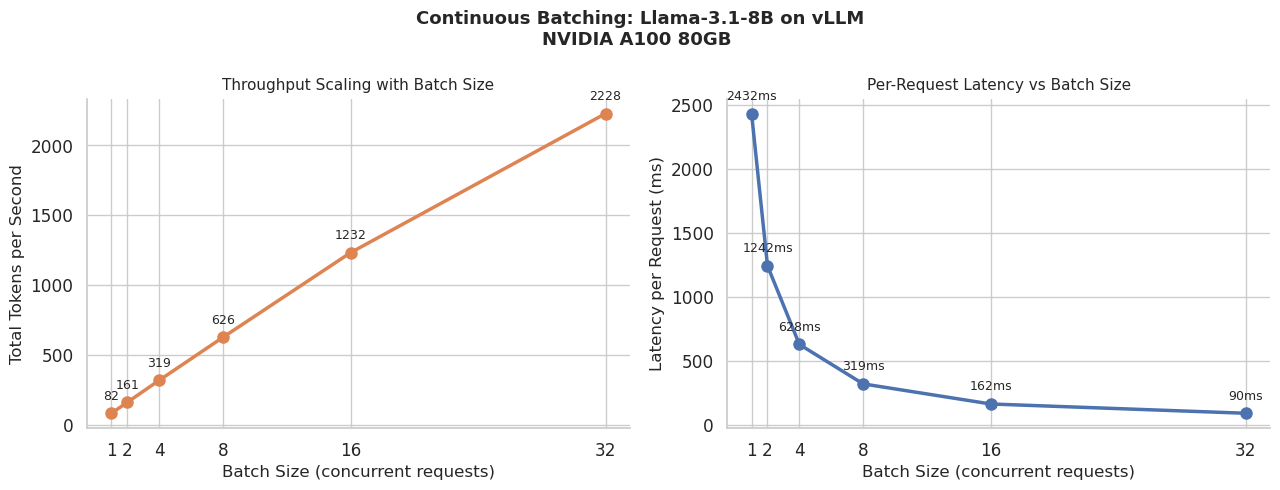

Continuous batching chart saved!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
batch_df = pd.read_csv("/data/pjiang18/SLP/LLMBenchmark/results/continuous_batching_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Continuous Batching: Llama-3.1-8B on vLLM\nNVIDIA A100 80GB ",
             fontsize=13, fontweight="bold")

ax1 = axes[0]
ax1.plot(batch_df["batch_size"], batch_df["tokens_per_sec"],
         marker="o", linewidth=2.5, color="#DD8452", markersize=8)
for x, y in zip(batch_df["batch_size"], batch_df["tokens_per_sec"]):
    ax1.annotate(f"{y:.0f}", (x, y), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=9)
ax1.set_xlabel("Batch Size (concurrent requests)", fontsize=12)
ax1.set_ylabel("Total Tokens per Second", fontsize=12)
ax1.set_title("Throughput Scaling with Batch Size", fontsize=11)
ax1.set_xticks(batch_df["batch_size"])
sns.despine(ax=ax1)

ax2 = axes[1]
ax2.plot(batch_df["batch_size"], batch_df["latency_ms_per_request"],
         marker="o", linewidth=2.5, color="#4C72B0", markersize=8)
for x, y in zip(batch_df["batch_size"], batch_df["latency_ms_per_request"]):
    ax2.annotate(f"{y:.0f}ms", (x, y), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=9)
ax2.set_xlabel("Batch Size (concurrent requests)", fontsize=12)
ax2.set_ylabel("Latency per Request (ms)", fontsize=12)
ax2.set_title("Per-Request Latency vs Batch Size", fontsize=11)
ax2.set_xticks(batch_df["batch_size"])
sns.despine(ax=ax2)

plt.tight_layout()
fig.savefig("/data/pjiang18/SLP/LLMBenchmark/results/08_continuous_batching.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Continuous batching chart saved!")

# KV Cache Analysis

In [16]:
import time
import torch
import numpy as np
import pandas as pd
from vllm import LLM, SamplingParams

HF_CACHE = "/data/datasets/community/huggingface"
MODEL_PATH = f"{HF_CACHE}/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659"

# Change these two lines in Cell 11
PROMPTS = [
    "Write a detailed essay on the history and evolution of artificial intelligence from the 1950s to present day.",
    "Explain in depth how large language models are trained, including pretraining, fine-tuning, and RLHF.",
    "Describe the complete architecture of the transformer model including all components and their mathematical operations.",
    "Write a comprehensive comparison of different neural network architectures including CNNs, RNNs, LSTMs, and Transformers.",
    "Explain the entire process of how GPT models generate text, from tokenization to sampling strategies.",
    "Describe in detail how attention mechanisms work mathematically and why they replaced recurrent architectures.",
    "Write a thorough explanation of gradient descent variants including SGD, Adam, RMSprop and their tradeoffs.",
    "Explain how distributed training works across multiple GPUs including data parallelism and model parallelism.",
]

GPU_UTILIZATIONS = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def clear_gpu():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    import gc; gc.collect()

sampling_params = SamplingParams(temperature=0.0, max_tokens=800)
kv_results = []

for gpu_util in GPU_UTILIZATIONS:
    print(f"Testing gpu_memory_utilization={gpu_util}")
    clear_gpu()

    try:
        llm = LLM(
            model=MODEL_PATH,
            trust_remote_code=True,
            dtype="float16",
            gpu_memory_utilization=gpu_util,
            max_model_len=2048,
            enforce_eager=True,
        )

        _ = llm.generate(PROMPTS[:1], SamplingParams(temperature=0.0, max_tokens=10))

        tps_list = []
        for run in range(3):
            t0 = time.perf_counter()
            outputs = llm.generate(PROMPTS, sampling_params)
            total_time = time.perf_counter() - t0
            total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
            tps = total_tokens / total_time
            tps_list.append(tps)

        avg_tps = np.mean(tps_list)
        vram_used = torch.cuda.memory_reserved() / 1e9

        print(f"  gpu_util={gpu_util} | {avg_tps:.1f} tok/s | VRAM reserved: {vram_used:.1f} GB")

        kv_results.append({
            "gpu_memory_utilization": gpu_util,
            "vram_reserved_gb": vram_used,
            "tokens_per_sec": avg_tps,
            "kv_cache_gb": round(gpu_util * 85.1 - 15.0, 1),
        })

        del llm
        clear_gpu()

    except Exception as e:
        print(f"  Failed at gpu_util={gpu_util}: {e}")
        clear_gpu()

kv_df = pd.DataFrame(kv_results)
kv_df.to_csv("/data/pjiang18/SLP/LLMBenchmark/results/kv_cache_results.csv", index=False)
print("\nKV cache results saved!")
print(kv_df.to_string(index=False))

Testing gpu_memory_utilization=0.3
WARNING 03-29 21:16:55 [config.py:2972] Casting torch.bfloat16 to torch.float16.
INFO 03-29 21:16:55 [config.py:717] This model supports multiple tasks: {'generate', 'score', 'reward', 'embed', 'classify'}. Defaulting to 'generate'.
INFO 03-29 21:16:55 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
WARNING 03-29 21:16:55 [cuda.py:93] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 03-29 21:17:01 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 03-29 21:17:02 [__init__.py:239] Automatically detected platform cuda.
INFO 03-29 21:17:05 [core.py:58] Initializing a V1 LLM engine (v0.8.5) with config: model='/data/datasets/community/huggingface/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894c89659', speculative_config=None, tokenizer='/data/datasets/community/huggingface/m

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:03<00:11,  3.93s/it]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:08<00:08,  4.04s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:12<00:04,  4.13s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:13<00:00,  2.93s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:13<00:00,  3.34s/it]



INFO 03-29 21:17:19 [loader.py:458] Loading weights took 13.40 seconds
INFO 03-29 21:17:19 [gpu_model_runner.py:1347] Model loading took 14.9889 GiB and 13.532677 seconds
ERROR 03-29 21:17:21 [core.py:396] EngineCore failed to start.
ERROR 03-29 21:17:21 [core.py:396] Traceback (most recent call last):
ERROR 03-29 21:17:21 [core.py:396]   File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/v1/engine/core.py", line 387, in run_engine_core
ERROR 03-29 21:17:21 [core.py:396]     engine_core = EngineCoreProc(*args, **kwargs)
ERROR 03-29 21:17:21 [core.py:396]                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ERROR 03-29 21:17:21 [core.py:396]   File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/v1/engine/core.py", line 329, in __init__
ERROR 03-29 21:17:21 [core.py:396]     super().__init__(vllm_config, executor_class, log_stats,
ERROR 03-29 21:17:21 [core.py:396]   File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/v1/eng

Process EngineCore_0:
Traceback (most recent call last):
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/v1/engine/core.py", line 400, in run_engine_core
    raise e
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/v1/engine/core.py", line 387, in run_engine_core
    engine_core = EngineCoreProc(*args, **kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/v1/engine/core.py", line 329, in __init__
    super().__init__(vllm_config, executor_class, log_stats,
  File "/data/pjiang18/SLP/envs/llm-bench/lib/python3.12/site-packages/vllm/v1/engine/core.py", line 71, in __init__
    self._i

  Failed at gpu_util=0.3: Engine core initialization failed. See root cause above.
Testing gpu_memory_utilization=0.4
WARNING 03-29 21:17:24 [config.py:2972] Casting torch.bfloat16 to torch.float16.
INFO 03-29 21:17:24 [config.py:717] This model supports multiple tasks: {'generate', 'score', 'reward', 'embed', 'classify'}. Defaulting to 'generate'.
INFO 03-29 21:17:24 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=16384.
WARNING 03-29 21:17:24 [cuda.py:93] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used
INFO 03-29 21:17:29 [importing.py:53] Triton module has been replaced with a placeholder.
INFO 03-29 21:17:30 [__init__.py:239] Automatically detected platform cuda.
INFO 03-29 21:17:32 [core.py:58] Initializing a V1 LLM engine (v0.8.5) with config: model='/data/datasets/community/huggingface/models--meta-llama--Llama-3.1-8B-Instruct/snapshots/0e9e39f249a16976918f6564b8830bc894

...

Processed prompts:   0%|          | 0/8 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts:   0%|          | 0/8 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  gpu_util=0.9 | 619.8 tok/s | VRAM reserved: 15.0 GB


[rank0]:[W329 21:22:46.550101679 ProcessGroupNCCL.cpp:1496] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())



KV cache results saved!
 gpu_memory_utilization  vram_reserved_gb  tokens_per_sec  kv_cache_gb
                    0.5           15.0219      621.217563         27.5
                    0.6           15.0219      616.454510         36.1
                    0.7           15.0219      620.540088         44.6
                    0.8           15.0219      622.205704         53.1
                    0.9           15.0219      619.759115         61.6


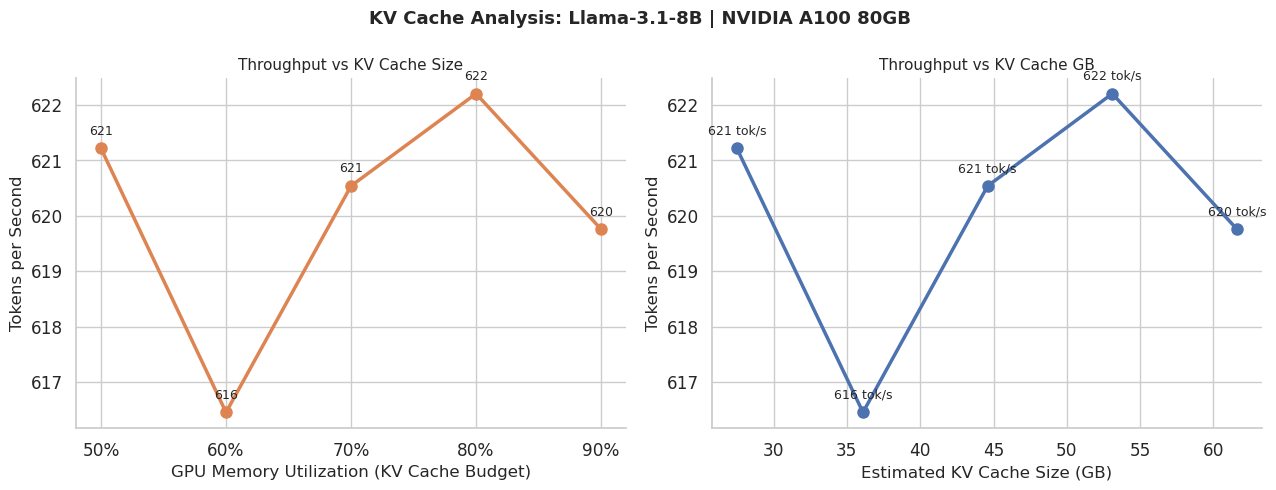

Saved.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", font_scale=1.1)
kv_df = pd.read_csv("/data/pjiang18/SLP/LLMBenchmark/results/kv_cache_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("KV Cache Analysis: Llama-3.1-8B | NVIDIA A100 80GB",
             fontsize=13, fontweight="bold")

ax1 = axes[0]
ax1.plot(kv_df["gpu_memory_utilization"], kv_df["tokens_per_sec"],
         marker="o", linewidth=2.5, color="#DD8452", markersize=8)
for x, y in zip(kv_df["gpu_memory_utilization"], kv_df["tokens_per_sec"]):
    ax1.annotate(f"{y:.0f}", (x, y), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=9)
ax1.set_xlabel("GPU Memory Utilization (KV Cache Budget)", fontsize=12)
ax1.set_ylabel("Tokens per Second", fontsize=12)
ax1.set_title("Throughput vs KV Cache Size", fontsize=11)
ax1.set_xticks(kv_df["gpu_memory_utilization"])
ax1.set_xticklabels([f"{x:.0%}" for x in kv_df["gpu_memory_utilization"]])
sns.despine(ax=ax1)

ax2 = axes[1]
ax2.plot(kv_df["kv_cache_gb"], kv_df["tokens_per_sec"],
         marker="o", linewidth=2.5, color="#4C72B0", markersize=8)
for x, y in zip(kv_df["kv_cache_gb"], kv_df["tokens_per_sec"]):
    ax2.annotate(f"{y:.0f} tok/s", (x, y), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=9)
ax2.set_xlabel("Estimated KV Cache Size (GB)", fontsize=12)
ax2.set_ylabel("Tokens per Second", fontsize=12)
ax2.set_title("Throughput vs KV Cache GB", fontsize=11)
sns.despine(ax=ax2)

plt.tight_layout()
fig.savefig("/data/pjiang18/SLP/LLMBenchmark/results/09_kv_cache_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")